In [1]:
import importlib
import torch

import model_code.data_setup as setup
import model_code.steering_extraction as steering_extraction
from model_code.steering_extraction import extractAllLayer, generateSteering, retrieve_steering_vector

importlib.reload(setup)
importlib.reload(steering_extraction)

/workspace/Dissertation_Project/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


<module 'model_code.steering_extraction' from '/workspace/Dissertation_Project/model_code/steering_extraction.py'>

In [1]:
model

NameError: name 'model' is not defined

In [4]:
!rm -rf /workspace/.cache/huggingface/hub
!rm -rf /workspace/.cache/pip
!df -h /workspace

Filesystem                Size  Used Avail Use% Mounted on
mfs#euro.runpod.net:9421  2.3P  1.6P  721T  69% /workspace


In [6]:
steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

/tmp/ipykernel_9079/3378552363.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors

In [ ]:
# Keep this in mind
emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21
eng_average_magnitudes = {emotion: 0 for emotion in emotions}
ind_average_magnitudes = {emotion: 0 for emotion in emotions}
for emotion in emotions:
    for layer in range(len(steering_vector_eng[emotion])):
        steer_id = torch.norm(steering_vector_id[emotion][layer]).item()
        steer_eng = torch.norm(steering_vector_eng[emotion][layer]).item()
        print("=" * 60)
        print(f"{emotion.upper()} INDONESIAN STEERING VECTOR - LAYER {layer +1}")
        print(f"Magnitude: {steer_id:.6f}")
        print(f"{emotion.upper()} ENGLISH STEERING VECTOR - LAYER {layer +1}")
        print(f"Magnitude: {steer_eng:.6f}")
        eng_average_magnitudes[emotion] += steer_eng
        ind_average_magnitudes[emotion] += steer_id


ANGER INDONESIAN STEERING VECTOR - LAYER 1
Magnitude: 0.029765
ANGER ENGLISH STEERING VECTOR - LAYER 1
Magnitude: 0.016240
ANGER INDONESIAN STEERING VECTOR - LAYER 2
Magnitude: 0.655240
ANGER ENGLISH STEERING VECTOR - LAYER 2
Magnitude: 0.150086
ANGER INDONESIAN STEERING VECTOR - LAYER 3
Magnitude: 0.657009
ANGER ENGLISH STEERING VECTOR - LAYER 3
Magnitude: 0.152117
ANGER INDONESIAN STEERING VECTOR - LAYER 4
Magnitude: 0.661341
ANGER ENGLISH STEERING VECTOR - LAYER 4
Magnitude: 0.161415
ANGER INDONESIAN STEERING VECTOR - LAYER 5
Magnitude: 0.667651
ANGER ENGLISH STEERING VECTOR - LAYER 5
Magnitude: 0.177147
ANGER INDONESIAN STEERING VECTOR - LAYER 6
Magnitude: 0.678719
ANGER ENGLISH STEERING VECTOR - LAYER 6
Magnitude: 0.191986
ANGER INDONESIAN STEERING VECTOR - LAYER 7
Magnitude: 0.692755
ANGER ENGLISH STEERING VECTOR - LAYER 7
Magnitude: 0.212023
ANGER INDONESIAN STEERING VECTOR - LAYER 8
Magnitude: 0.708809
ANGER ENGLISH STEERING VECTOR - LAYER 8
Magnitude: 0.229299
ANGER INDONESIAN

In [14]:
len(steering_vector_eng['anger'])

32

In [13]:

for emotion in emotions:
    eng_average_magnitudes[emotion] /= len(steering_vector_eng[emotion])
    ind_average_magnitudes[emotion] /= len(steering_vector_id[emotion])
    print("=" * 60)
    print(f"{emotion.upper()} AVERAGE STEERING VECTOR MAGNITUDE")
    print(f"English: {eng_average_magnitudes[emotion]:.6f}")
    print(f"Indonesian: {ind_average_magnitudes[emotion]:.6f}")


ANGER AVERAGE STEERING VECTOR MAGNITUDE
English: 0.017729
Indonesian: 0.036603
HAPPINESS AVERAGE STEERING VECTOR MAGNITUDE
English: 0.027172
Indonesian: 0.036680
SADNESS AVERAGE STEERING VECTOR MAGNITUDE
English: 0.013714
Indonesian: 0.018467
LOVE AVERAGE STEERING VECTOR MAGNITUDE
English: 0.016843
Indonesian: 0.034484
FEAR AVERAGE STEERING VECTOR MAGNITUDE
English: 0.020002
Indonesian: 0.027970


,emotion,layer,cosine_similarity
0,anger,0,0.262442
1,anger,1,0.986448
2,anger,2,0.968251
3,anger,3,0.919748
4,anger,4,0.855297


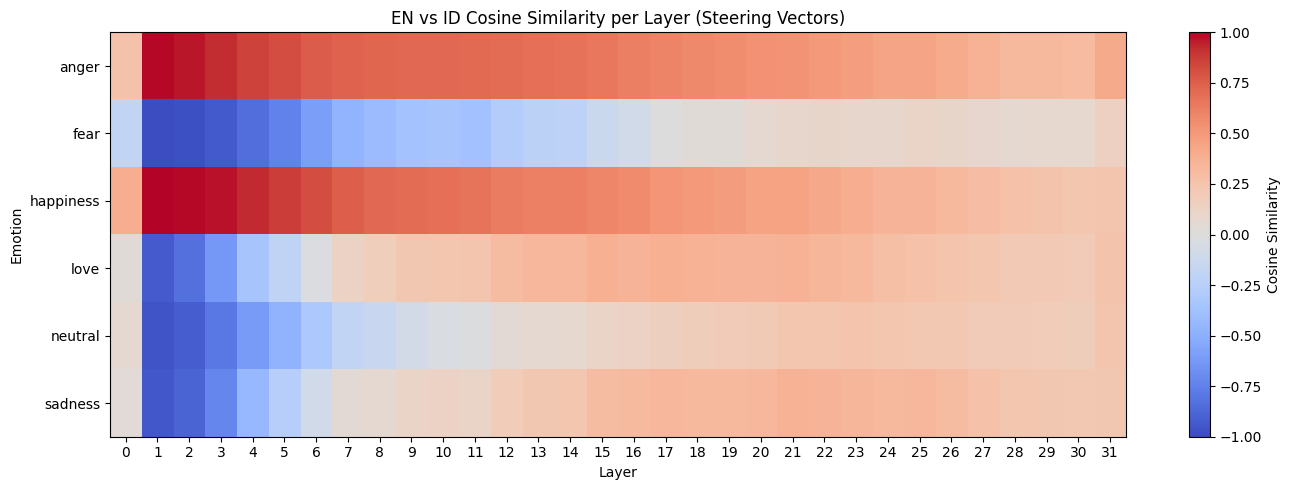

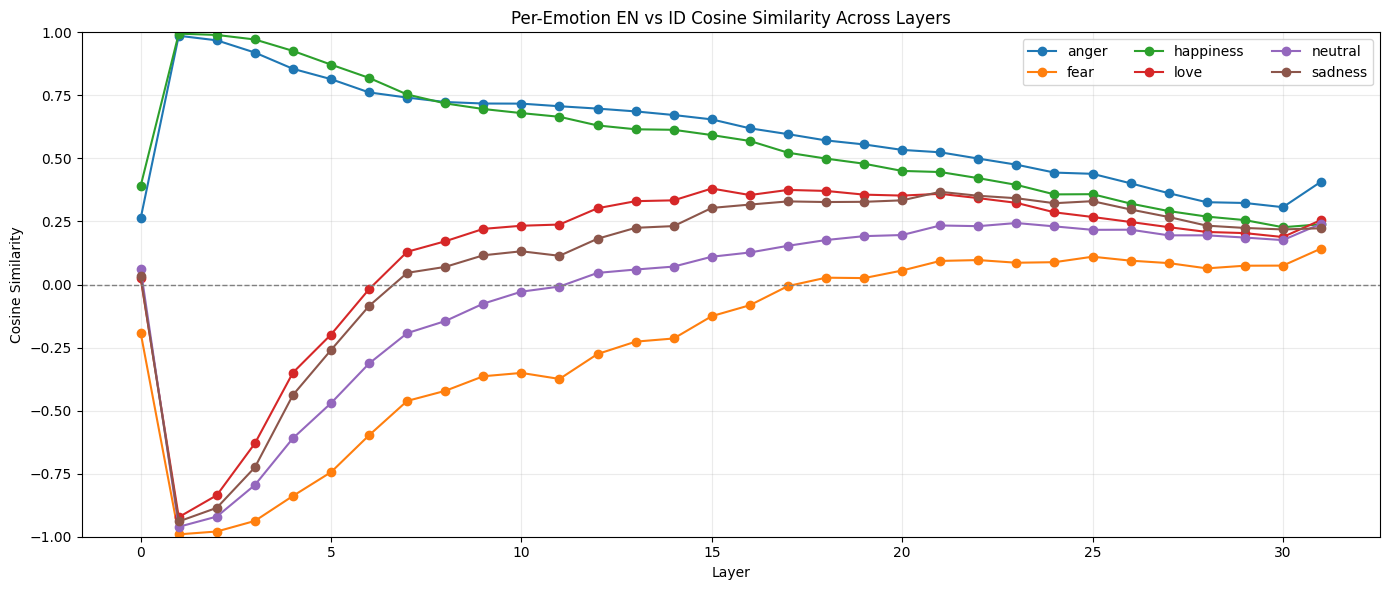

,mean,min,max
emotion,,,
anger,0.602258,0.262442,0.986448
happiness,0.563509,0.227269,0.994790
love,0.129181,-0.922400,0.380684
sadness,0.091719,-0.939441,0.367609
neutral,-0.029900,-0.960747,0.243885
fear,-0.220618,-0.990620,0.142518


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Cosine similarity per layer between EN and ID steering vectors for each emotion
emotions = ["anger", "happiness", "sadness", "love", "fear", "neutral"]
available_emotions = [
    e for e in emotions
    if e in steering_vector_eng and e in steering_vector_id
]

records = []
for emotion in available_emotions:
    en_vec = steering_vector_eng[emotion]
    id_vec = steering_vector_id[emotion]

    if en_vec.shape != id_vec.shape:
        raise ValueError(
            f"Shape mismatch for emotion '{emotion}': EN {en_vec.shape} vs ID {id_vec.shape}"
        )

    layer_sims = F.cosine_similarity(en_vec, id_vec, dim=1)
    for layer_idx, sim in enumerate(layer_sims.tolist()):
        records.append(
            {
                "emotion": emotion,
                "layer": layer_idx,
                "cosine_similarity": sim,
            }
        )

cosine_df = pd.DataFrame(records)
display(cosine_df.head())

# Pivot for heatmap-like matrix: rows = emotions, cols = layers
heatmap_df = cosine_df.pivot(index="emotion", columns="layer", values="cosine_similarity")

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns)
plt.xlabel("Layer")
plt.ylabel("Emotion")
plt.title("EN vs ID Cosine Similarity per Layer (Steering Vectors)")
plt.tight_layout()
plt.show()

# Line plot per emotion across layers
plt.figure(figsize=(14, 6))
for emotion in heatmap_df.index:
    plt.plot(heatmap_df.columns, heatmap_df.loc[emotion].values, marker="o", linewidth=1.5, label=emotion)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Per-Emotion EN vs ID Cosine Similarity Across Layers")
plt.legend(loc="best", ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Optional summary table (mean/min/max similarity per emotion)
summary_df = (
    cosine_df.groupby("emotion")["cosine_similarity"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(summary_df)